# Paper-exact reproduction: the Addition circuit on Qwen3-4B

**v3 (clean-room rebuild, 2026-07-14).** Reproduces the *Addition* case study of
[On the Biology of a Large Language Model](https://transformer-circuits.pub/2025/attribution-graphs/biology.html)
on Qwen3-4B with mwhanna per-layer transcoders, following `multilingual.ipynb`'s template:
**selection lives in the reviewed artifact** `supernodes/addition_4b.json`, reviewed in the
**grid-enabled explorer** (every feature node shows its operand plots at the paper's
`=`/ones moments) and ingested by `build_supernodes.py`; this notebook only *drives* those
supernodes.

The paper's claims under reproduction: the model answers `calc: a+b=` through **parallel
pathways** — input-digit features (`_6`, `_9`), low-precision **magnitude** features, a
high-precision **lookup table** (`_6+_9`), and **sum** features (`sum = _5`, `sum ~95`) —
identified by operand-plot geometry, validated by **suppression** and by **substituting**
the lookup with a `_9+_9` donor (ones digit 5 → 8); the same lookup features **fire in
prose** (a citation-style prompt) and the model's **self-report** describes the carry
algorithm the graphs do not show.

Qwen3 facts that adapt the protocol (see `addition_helper.py`): digits tokenize one by one,
so the answer has a **first-digit** moment (`…=`) and a teacher-forced **ones-digit** moment
(`…=9`); Qwen3-4B misses the paper's 36+59, so the studied pair is the nearest correctly
answered pair of the same ones-digit class (recorded in the dumps' manifest). Steering uses
the additive convention `m = M_paper − 1`.

Run on a GPU node: `sbatch hpc/run_addition_notebook.sbatch` (inputs from
`sbatch hpc/run_supernode_inputs.sbatch`, review via `build_supernodes.py`).

## What actually runs — inputs, supernodes, artifacts

**Graphs (loaded from the reviewed dumps, `supernode_inputs/4b/`):**

| dump | prompt | analyzed moment |
|---|---|---|
| `first` | `calc: a+b=` | the sum's first digit at `=` |
| `ones` | `calc: a+b=<leading digits>` | the teacher-forced ones digit |
| `donor` | the `_9+_9`-class pair, ones moment | donor lookup features for §D |
| `reuse` | citation-style prose, ones moment | the same fact in context (§E) |

**Supernodes** come exclusively from `supernodes/addition_4b.json` (approved =
hand-reviewed; the loader refuses anything else). Canonical names are pair-parametric
(`build_supernodes.addition_names`): `input _6`/`input _9` (sources at the operand ones
digits), `magnitude ~a`/`~b` + `add ~b (function)` + `magnitude lookup` + `sum ~s (low
precision)` (the first-digit magnitude path), `lookup (_6+_9)` + `sum = _5` (the ones
modular path), `lookup (_9+_9) donors`, `reuse lookups`. Interventions are **constrained
patching** (`patch_end_layer` swept and pinned per experiment; attention frozen), the
paper's protocol.

**Artifacts** land in `artifacts/paper_addition/4b/`: explorer HTMLs with grids + reviewed
groups, `grids_supernodes.png`, `behavior.json`, `suppressions.json`, `swap_sweep.{json,png}`,
`reuse.json`, `introspection.json`, `corpus_scan.json`, `verdicts.json`.


In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path.cwd()))
import addition_helper as A
import build_supernodes as BS

from llm_circuits.circuits.graph_explorer import render_graph_explorer_html
from llm_circuits.circuits.interventions import run_feature_intervention
from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder
from llm_circuits.utils import seed_everything

SIZE = "4b"
seed_everything(0, deterministic=True)
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE
OUT = artifacts_dir() / "paper_addition" / SIZE
OUT.mkdir(parents=True, exist_ok=True)

manifest = json.loads((SN_INPUTS / "manifest.json").read_text())
mg = manifest["graphs"]
A0, B0 = manifest["addition"]["pair"]
DA, DB = manifest["addition"]["donor_pair"]
S0 = A0 + B0
RA, RB, O0 = A0 % 10, B0 % 10, S0 % 10
NAMES = BS.addition_names(manifest)
SN = A.load_supernodes(Path("supernodes") / f"addition_{SIZE}.json")
missing = [n for n in NAMES if n not in SN or not SN[n]["members"]]
print(f"pair {A0}+{B0}={S0} ({manifest['addition']['pair_note']}); donor {DA}+{DB}")
print(f"supernodes: {len(SN)} loaded; canonical empty/missing: {missing or 'none'}")

device = "cuda" if torch.cuda.is_available() else "cpu"
model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=device)
model.eval()
tc = load_transcoder(
    f"qwen3-{SIZE}", device=device, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
ctx = BS.load_grid_ctx(SN_INPUTS)
GRAPH_NAMES = ("first", "ones", "donor", "reuse")
graphs = {g: json.loads((SN_INPUTS / f"graph_{g}.json").read_text()) for g in GRAPH_NAMES}
fin = {g: mg[g]["final_position"] for g in GRAPH_NAMES}
ans_id = {g: mg[g]["answer_token_id"] for g in GRAPH_NAMES}
ids_of = {g: A.tokenize_raw(tokenizer, mg[g]["prompt"], device) for g in GRAPH_NAMES}
for g in GRAPH_NAMES:
    assert ids_of[g].shape[1] == mg[g]["n_tokens"], f"{g}: tokenization drifted vs the dumps"

pair 36+49=85 (paper pair 36+59 answered wrong; nearest correct same-class pair 36+49); donor 39+49
supernodes: 13 loaded; canonical empty/missing: ['magnitude ~49', 'magnitude lookup (~36+~49)', 'reuse lookups (_6+_9)']


[07/16/26 01:06:20] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/models)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/16/26 01:06:47] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/home/zw499/rds/hpc-work/llm-circuits/.cache/transcoders)

## 0. Behavior — accuracy over all 10,000 problems, the studied pair, the prompts

The paper's model answers `calc: 36+59=` correctly; Qwen3-4B's competence is patchier, so
the reproduction first maps it (greedy decoding over every `a+b`, a,b ∈ 0..99) and studies
the nearest correct pair of the paper's ones-digit class (`_6+_9`). The donor pair is the
nearest correct `_9+_9` problem (its true ones digit is 8 — the §D substitution target).


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


first                                                'calc: 36+49=' -> '85, ' (expected '8')
ones                                                'calc: 36+49=8' -> '5, 8' (expected '5')


donor                                               'calc: 39+49=8' -> '8? 3' (expected '8')


reuse  'The journal Annals of Applied Analysis was founded in 1949. Counting one volume per year, volume 36 appeared in 198' -> '1. What is' (expected '5')


488

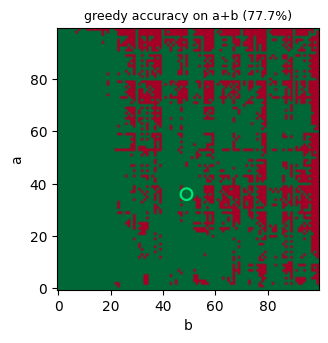

In [2]:
if (SN_INPUTS / "accuracy_correct.npy").exists():
    acc = np.load(SN_INPUTS / "accuracy_correct.npy")
else:  # the dump job reused a recorded pair; recompute for the figure (~2 min)
    acc, _ = A.accuracy_grid(model, tokenizer)
ax = A.plot_accuracy(acc)
ax.scatter([B0], [A0], s=70, facecolors="none", edgecolors="#00e676", lw=1.6)
ax.figure.savefig(OUT / "accuracy_grid.png", dpi=150, bbox_inches="tight")

behavior = {"accuracy_pct": round(float(acc.mean()) * 100, 2)}
for g in GRAPH_NAMES:
    _, cont = A.greedy_answer(model, tokenizer, ids_of[g], n_gen=4)
    expected = mg[g].get("expected_answer", mg[g]["answer"])
    behavior[g] = {"prompt": mg[g]["prompt"], "continuation": cont, "expected": expected}
    print(f"{g:6s} {mg[g]['prompt']!r:>60s} -> {cont!r} (expected {expected!r})")
(OUT / "behavior.json").write_text(json.dumps(behavior, indent=1, ensure_ascii=False))

## A. Attribution graphs — the four dumped circuits, explorer HTMLs with grids + groups

Graphs were built and pruned once by `build_supernode_inputs.py` (recorded thresholds in
the manifest); here they are re-exported as **grid-enabled explorer pages with the
reviewed supernodes pre-loaded as groups** — the same view the selection was made in.


In [3]:
def groups_for(gname):
    specs = []
    for name, sn in SN.items():
        if sn["graph"] != gname or not sn["members"]:
            continue
        pos = sn["position"]
        specs.append(
            {
                "name": name,
                "members": [(m["layer"], m["feature"]) for m in sn["members"]],
                "position": pos if pos == "final" or isinstance(pos, int) else None,
            }
        )
    return specs


for g in GRAPH_NAMES:
    n_feat = sum(1 for n in graphs[g]["nodes"] if n["node_type"] == "feature")
    wired = BS.attach_operand_grids(graphs[g], g, mg[g], ctx)
    render_graph_explorer_html(
        wired,
        OUT / f"graph_{g}.html",
        labels=[g],
        title=f"addition {g} ({A0}+{B0})",
        groups=groups_for(g),
    )
    print(f"{g:6s} {n_feat:5d} feature nodes, {len(groups_for(g)):2d} groups -> graph_{g}.html")

first   1426 feature nodes,  3 groups -> graph_first.html


ones    1340 feature nodes,  6 groups -> graph_ones.html


donor   1405 feature nodes,  1 groups -> graph_donor.html


reuse    164 feature nodes,  0 groups -> graph_reuse.html


## B. Supernodes — the reviewed selection and its operand-grid evidence

**Probe policy (aligned to the paper).** Operand plots for analysis are read only at the
two answer moments the paper uses: `final` (the `=` token — the paper's exact convention,
for the first-digit graph) and `ones` (the teacher-forced ones-digit moment — the paper's
`=` mapped through Qwen3's digit-by-digit tokenization). The `peak` (max-over-positions)
probe is kept on the interactive review pages for inspecting input features but is **not
used for analysis here**.

A consequence specific to Qwen3: the **operand-position** supernodes (`input _6`,
`input _9`, `magnitude ~a`) are silent at the answer token — the model consumes operand
identity *before* `=`, unlike Haiku where the paper reads these at `=`. Their identity was
established on the review pages (peak) and their causal role is carried by the
attribution-graph **edges** into the lookup/sum features and by the **suppression**
interventions in §C (both probe-independent). The evidence figure below therefore shows
the answer-moment operand plots and lists operand-position supernodes separately. Sum-side
groups also get their **direct decoder weights** on the ten digit tokens (`sum = _5`
should write "5").

*Note on this pair:* Qwen3's operand features for 36+49 are **exact-value** (`cross(36)`,
`cross(49)` — a full row/column), not mod-10 lattices, so `input _6` and `input 36
(exact)` hold disjoint exact-value features rather than the paper's distinct
ones-digit-vs-full-operand split.

supernode                        role       graph  pos     n  grid classes
input _6                         source     ones   5       6  cross(36)
input _9                         source     ones   8       6  cross(49); mod10-a(r9); mod10-b(r9)
input 36 (exact)                 annotation ones   None    6  band-a(~30); cross(36); mixed; mod10-a(r6)
input 49 (exact)                 annotation ones   None    6  cross(49); mixed; sparse
magnitude ~36                    source     first  None    6  band-a(~31); band-a(~32); band-a(~34); band-a(~35); band-a(~38)
magnitude ~49                    source     first  None    0  
add ~49 (function)               annotation first  final   2  band-b(~46)
magnitude lookup (~36+~49)       annotation first  final   0  
sum ~85 (low precision)          readout    first  final   6  sum-band(~81); sum-band(~85); sum-band(~89)
lookup (_6+_9)                   source     ones   final   1  mod10-sum(r5)
sum = _5                         readout    ones   fina


grids_supernodes.png: 21 answer-moment member grids
operand-position supernodes (silent at the answer moment; see review pages): input _6, input _9, input 36 (exact), input 49 (exact), magnitude ~36


L25f 33199 direct digit weights: argmax '8' (+0.299)
L26f138203 direct digit weights: argmax '4' (+0.142)
L26f 84235 direct digit weights: argmax '8' (+0.123)
L26f 28445 direct digit weights: argmax '8' (+0.172)
L27f 77434 direct digit weights: argmax '5' (+0.546)
L27f 72987 direct digit weights: argmax '5' (+0.404)
L27f132398 direct digit weights: argmax '9' (+0.121)
L28f  5743 direct digit weights: argmax '5' (+0.070)
L28f154805 direct digit weights: argmax '2' (+0.161)
L29f 80619 direct digit weights: argmax '5' (+0.435)
L29f  5939 direct digit weights: argmax '8' (+0.693)
L29f128200 direct digit weights: argmax '4' (+0.036)


1603

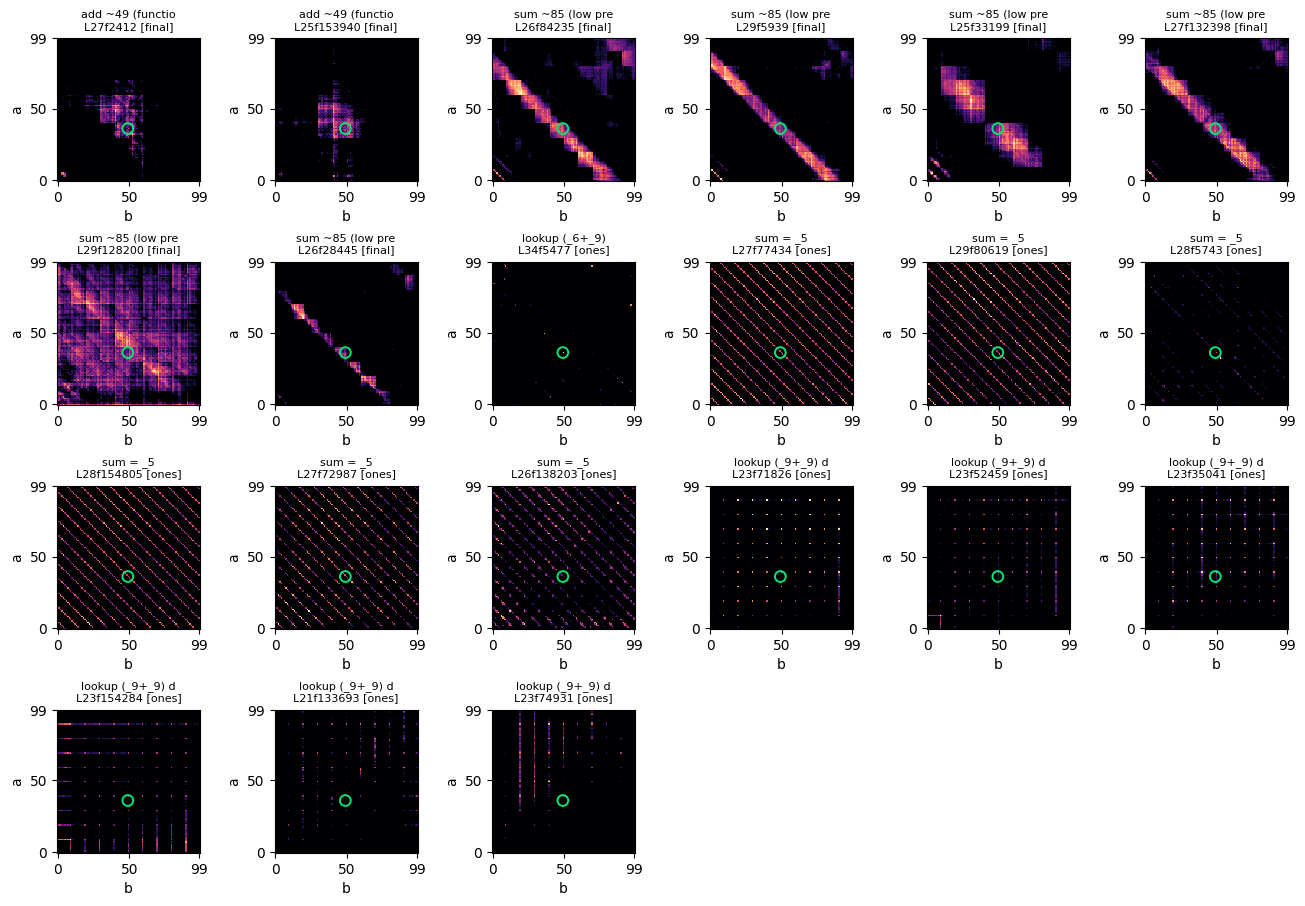

In [4]:
print(f"{'supernode':32s} {'role':10s} {'graph':6s} {'pos':6s} {'n':>2s}  grid classes")
for name, sn in SN.items():
    classes = sorted({str((m.get("evidence") or {}).get("grid_class")) for m in sn["members"]})
    print(
        f"{name:32s} {sn['role']:10s} {sn['graph']:6s} {sn['position']!s:6s} "
        f"{len(sn['members']):2d}  {'; '.join(classes)[:70]}"
    )


# operand plots at the paper's answer moments only (ones / final); peak is display-only on
# the review pages. Operand-position supernodes go silent here — listed, not plotted.
def analysis_probe(gname):
    return "ones" if str(mg[gname].get("target", "")) in ("ones", "reuse-ones") else "final"


items, silent = [], []
for name, sn in SN.items():
    if not sn["members"]:
        continue
    probe = analysis_probe(sn["graph"])
    live = [
        (ctx.grid(probe, m["layer"], m["feature"]), m["layer"], m["feature"]) for m in sn["members"]
    ]
    live = [(g, layer, feat) for g, layer, feat in live if g is not None and g.max() > 0]
    if not live:
        silent.append(name)
        continue
    for g, layer, feat in live:
        items.append((g, f"{name[:16]}\nL{layer}f{feat} [{probe}]"))
fig = A.plot_grid_panels(items, ncols=6, mark=(A0, B0))
fig.savefig(OUT / "grids_supernodes.png", dpi=130, bbox_inches="tight")
print(f"\ngrids_supernodes.png: {len(items)} answer-moment member grids")
if silent:
    print(
        "operand-position supernodes (silent at the answer moment; see review pages): "
        + ", ".join(silent)
    )

sum_groups = [f"sum = _{O0}", f"sum ~{S0} (low precision)"]
sum_feats = [(m["layer"], m["feature"]) for n in sum_groups if SN.get(n) for m in SN[n]["members"]]
weights = A.digit_direct_weights(model, tc, sum_feats, tokenizer) if sum_feats else {}
for (layer, feat), w in weights.items():
    top = int(np.argmax(w))
    print(f"L{layer:2d}f{feat:6d} direct digit weights: argmax '{top}' ({w[top]:+.3f})")
(OUT / "direct_weights.json").write_text(
    json.dumps({f"L{L}f{f}": w for (L, f), w in weights.items()}, indent=1)
)

## C. Suppression interventions — each pathway's causal role (paper's inhibition tests)

Each source supernode is suppressed at its members' own node positions under constrained
patching, at two strengths: **ablate** (`M=0`, `m=−1`) and the paper's **sign flip**
(`M=−1`, `m=−2`). The patch end layer ℓ is chosen per intervention by the paper's recipe
(sweep ℓ, keep the most-suppressing). Reported per run: the answer-token shift, the
**ones-digit distribution** and its smear width, and %-readouts of the *downstream*
supernodes (per-feature ratio, pinned members excluded) — the paper's arrows:
inputs → lookup → sum, magnitudes → sum-band.


In [5]:
# Genuine DOWNSTREAM targets per source (the paper's arrows) — NOT sibling supernodes:
# suppressing input _6 correlates with the other exact-36 input group, but that is not the
# input -> lookup -> sum pathway, so readouts are restricted to the real targets.
DOWNSTREAM = {
    f"input _{RA}": [f"lookup (_{RA}+_{RB})", f"sum = _{O0}"],
    f"input _{RB}": [f"lookup (_{RA}+_{RB})", f"sum = _{O0}"],
    f"lookup (_{RA}+_{RB})": [f"sum = _{O0}"],
    f"magnitude ~{A0}": [
        f"add ~{B0} (function)",
        f"magnitude lookup (~{A0}+~{B0})",
        f"sum ~{S0} (low precision)",
    ],
    f"magnitude ~{B0}": [
        f"add ~{B0} (function)",
        f"magnitude lookup (~{A0}+~{B0})",
        f"sum ~{S0} (low precision)",
    ],
}


def downstream_of(name):
    return {
        n: (SN[n], "baseline") for n in DOWNSTREAM.get(name, []) if SN.get(n, {}).get("members")
    }


SUPPRESS = [
    n
    for n in (
        f"input _{RA}",
        f"input _{RB}",
        f"lookup (_{RA}+_{RB})",
        f"magnitude ~{A0}",
        f"magnitude ~{B0}",
    )
    if SN.get(n, {}).get("members")
]
suppress_results = {}
for name in SUPPRESS:
    g = SN[name]["graph"]
    tok = tokenizer.decode([ans_id[g]])
    for mult in (0.0, -1.0):
        ivs = A.suppress_ivs(SN[name], mult=mult, final_pos=fin[g])
        ell, sweep = A.choose_end_layer(model, tc, ids_of[g], ivs, ans_id[g], mode="suppress")
        rep = A.steer_report(
            model,
            tc,
            tokenizer,
            ids_of[g],
            ivs,
            patch_end_layer=ell,
            readout_sns=downstream_of(name),
            final_pos=fin[g],
        )
        rep["graph"], rep["mult"], rep["ell"] = g, mult, ell
        rep["p_answer_before"] = sweep.baseline_prob
        rep["p_answer_after"] = sweep.probs[sweep.end_layers.index(ell)]
        suppress_results[f"{name} @ M={mult:+.0f}"] = rep
        ro = {
            n: r["mean_pct"]
            for n, r in rep["readouts"].items()
            if r["mean_pct"] is not None and r["n_used"]
        }
        print(
            f"{name:26s} M={mult:+.0f} ell={ell:2d}  p({tok.strip()!r}) "
            f"{rep['p_answer_before']:.3f}->{rep['p_answer_after']:.3f}  "
            f"top after: {rep['top_after'][0]}  width {rep['width_before']}->"
            f"{rep['width_after']}  downstream readouts {ro}"
        )
(OUT / "suppressions.json").write_text(json.dumps(suppress_results, indent=1, ensure_ascii=False))

input _6                   M=+0 ell=15  p('5') 1.000->1.000  top after: ('5', 0.999)  width 1.0->1.0  downstream readouts {'lookup (_6+_9)': 105.3, 'sum = _5': 102.0}


input _6                   M=-1 ell= 8  p('5') 1.000->1.000  top after: ('5', 0.999)  width 1.0->1.0  downstream readouts {'lookup (_6+_9)': 99.4, 'sum = _5': 99.0}


input _9                   M=+0 ell= 6  p('5') 1.000->1.000  top after: ('5', 1.0)  width 1.0->1.0  downstream readouts {'lookup (_6+_9)': 104.7, 'sum = _5': 102.8}


input _9                   M=-1 ell=12  p('5') 1.000->1.000  top after: ('5', 0.999)  width 1.0->1.0  downstream readouts {'lookup (_6+_9)': 109.9, 'sum = _5': 101.6}


lookup (_6+_9)             M=+0 ell=35  p('5') 1.000->1.000  top after: ('5', 0.999)  width 1.0->1.0  downstream readouts {}


lookup (_6+_9)             M=-1 ell=35  p('5') 1.000->1.000  top after: ('5', 0.999)  width 1.0->1.0  downstream readouts {}


magnitude ~36              M=+0 ell=17  p('8') 0.758->0.707  top after: ('8', 0.707)  width 1.01->1.02  downstream readouts {'add ~49 (function)': 89.3, 'sum ~85 (low precision)': 76.3}


magnitude ~36              M=-1 ell=18  p('8') 0.758->0.354  top after: ('8', 0.354)  width 1.01->1.23  downstream readouts {'add ~49 (function)': 69.8, 'sum ~85 (low precision)': 44.3}


10036

## D. The lookup substitution — inject the `_9+_9` donor, let the sum recompute (paper: 5 → 8)

The paper replaces the studied `_6+_9` lookup with a `_9+_9` donor and the ones digit
changes 5 → 8. On Qwen3 the crisp `_6+_9` lattice feature sits at **L34 — downstream of
the sum features (L26–28)**, so it is not the paper's *upstream* source; suppressing it
would only pin the constrained-patching floor above the sums and block propagation (the
degenerate ℓ=35 case).

The faithful analog here injects the **donor `_9+_9` lookup features** (upstream, ~L21–23)
at the ones-moment answer position and sweeps the patch end layer **down to where the sum
features can recompute** (`mode="promote"` picks the most-`8`-promoting ℓ), on an extended
ramp past the paper's ×1 endpoint. If the donor evidence drives the ones digit toward 8,
the substitution transfers; if the digit holds, that is an honest negative — expected
here because the teacher-forced first digit already fixes the answer (see the Summary).

ell=23 (donor layers [21, 23]); crossover at s=None (paper endpoint s=1)
  s= 0.0  p(5)=1.000  p(8)=0.000  top ['5', '4', '6']
  s= 0.5  p(5)=0.999  p(8)=0.000  top ['5', '4', '6']
  s= 1.0  p(5)=0.999  p(8)=0.000  top ['5', '4', '6']
  s= 2.0  p(5)=0.999  p(8)=0.000  top ['5', '6', '4']
  s= 4.0  p(5)=0.060  p(8)=0.003  top ['6', '5', '1']
  s= 8.0  p(5)=0.006  p(8)=0.002  top ['1', '2', '0']


1163

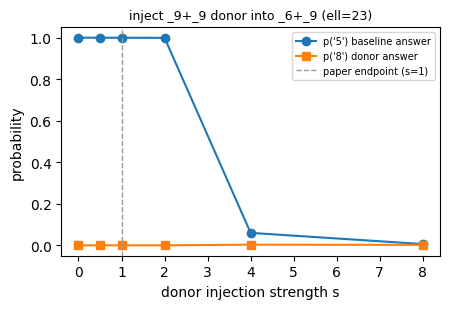

In [6]:
lookup_name, donor_name = f"lookup (_{RA}+_{RB})", f"lookup (_{DA % 10}+_{DB % 10}) donors"
expected_digit = str((DA + DB) % 10)
expected_id = tokenizer(expected_digit, add_special_tokens=False).input_ids[0]
baseline_id = ans_id["ones"]


# Inject the donor _9+_9 lookups (upstream, ~L21-23) at the ones answer position; do NOT
# suppress the studied L34 lookup (it is downstream of the sums, so steering it would pin
# the patch floor above them). choose_end_layer sweeps ell down to where the sum features
# (L26-28) recompute in response to the injected donor evidence.
def swap_ivs(s):
    if s == 0:
        return []
    inj, _used = A.inject_ivs(SN[donor_name], mult=s, positions=[fin["ones"]])
    return inj


ell, endpoint_sweep = A.choose_end_layer(
    model, tc, ids_of["ones"], swap_ivs(1.0), expected_id, mode="promote"
)
ladder = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
swap = {"ell": ell, "ladder": ladder, "p_base": [], "p_exp": [], "top": []}
for s in ladder:
    ivs = swap_ivs(s)
    res = run_feature_intervention(
        model,
        tc,
        ids_of["ones"],
        ivs,
        n_bos_tokens=A.N_BOS,
        patch_end_layer=ell if ivs else None,
    )
    probs = res.ablated_logits[-1].float().softmax(-1)
    swap["p_base"].append(float(probs[baseline_id]))
    swap["p_exp"].append(float(probs[expected_id]))
    swap["top"].append(A.top_token_probs(res.ablated_logits[-1], tokenizer, 4))
swap["crossover"] = next(
    (s for s, pb, pe in zip(ladder, swap["p_base"], swap["p_exp"], strict=True) if pe > pb),
    None,
)
print(
    f"ell={ell} (donor layers {sorted({m['layer'] for m in SN[donor_name]['members']})}); "
    f"crossover at s={swap['crossover']} (paper endpoint s=1)"
)
for s, pb, pe, top in zip(ladder, swap["p_base"], swap["p_exp"], swap["top"], strict=True):
    print(
        f"  s={s:4.1f}  p({O0})={pb:.3f}  p({expected_digit})={pe:.3f}  top {[t[0] for t in top[:3]]}"
    )

fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.plot(ladder, swap["p_base"], "o-", label=f"p('{O0}') baseline answer")
ax.plot(ladder, swap["p_exp"], "s-", label=f"p('{expected_digit}') donor answer")
ax.axvline(1.0, color="#999", ls="--", lw=1, label="paper endpoint (s=1)")
ax.set_xlabel("donor injection strength s")
ax.set_ylabel("probability")
ax.set_title(f"inject _{DA % 10}+_{DB % 10} donor into _{RA}+_{RB} (ell={ell})", fontsize=9)
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(OUT / "swap_sweep.png", dpi=150)
(OUT / "swap_sweep.json").write_text(json.dumps(swap, indent=1))

## E. Reuse in context — the same lookup fires (and acts) in prose

The citation-style prompt encodes the same ones-digit fact ("founded in 19{b}, volume {a}
→ 19{a+b}"). Checks: (i) behavior; (ii) the calc lookup members' activations at the reuse
ones moment (from the dumps); (iii) suppressing the reviewed `reuse lookups` group moves
the prose answer too.


In [7]:
reuse = {
    "prompt": mg["reuse"]["prompt"],
    "behavior_ok": bool(mg["reuse"].get("behavior_ok")),
    "continuation": behavior["reuse"]["continuation"],
}
acts = json.loads((SN_INPUTS / "reuse_moment_acts.json").read_text())
active = {(layer, feat): a for layer, feat, a in acts["active_final"]}
reuse["lookup_acts"] = []
for m in SN[lookup_name]["members"]:
    a = active.get((m["layer"], m["feature"]), 0.0)
    reuse["lookup_acts"].append([m["layer"], m["feature"], m["act"], a])
    print(
        f"lookup L{m['layer']:2d}f{m['feature']:6d}  calc act {m['act']:6.2f}   "
        f"reuse-moment act {a:6.2f}"
    )

rg = SN.get(f"reuse lookups (_{RA}+_{RB})")
if rg and rg["members"]:
    ivs = A.suppress_ivs(rg, mult=-1.0, final_pos=fin["reuse"])
    ell_r, _ = A.choose_end_layer(model, tc, ids_of["reuse"], ivs, ans_id["reuse"], mode="suppress")
    rep = A.steer_report(
        model, tc, tokenizer, ids_of["reuse"], ivs, patch_end_layer=ell_r, final_pos=fin["reuse"]
    )
    reuse["suppression"] = {
        "ell": ell_r,
        "top_before": rep["top_before"][:3],
        "top_after": rep["top_after"][:3],
    }
    print(
        f"suppress reuse lookups @ M=-1, ell={ell_r}: {rep['top_before'][0]} -> {rep['top_after'][0]}"
    )
else:
    reuse["suppression"] = None
    print("no reviewed reuse-lookup group — suppression skipped (documented absence)")
(OUT / "reuse.json").write_text(json.dumps(reuse, indent=1, ensure_ascii=False))

lookup L34f  5477  calc act  10.69   reuse-moment act   0.00
no reviewed reuse-lookup group — suppression skipped (documented absence)


273

## F. Introspection — the model's self-report vs the mechanism

The paper asks "Briefly, how did you get that?" and gets the schoolbook carry algorithm —
not the lookup/magnitude pathways the graphs show ("a capability without metacognitive
insight into it").


In [8]:
intro = A.introspection_dialogue(model, tokenizer, A0, B0)
print(f"Q: {intro['question']}\nA: {intro['answer']}\nQ: {intro['how']}\nA: {intro['explanation']}")
algo_words = ("carry", "ones", "tens", "units", "add the", "then add", "column")
intro["mentions_algorithm"] = any(w in intro["explanation"].lower() for w in algo_words)
intro["mentions_lookup"] = "lookup" in intro["explanation"].lower()
(OUT / "introspection.json").write_text(json.dumps(intro, indent=1, ensure_ascii=False))

Q: What is 36+49? Answer with just the number.
A: 85
Q: Briefly, how did you get that?
A: I added 36 and 49 together:  
36 + 49 = 85.


242

## G. Corpus scan — where the circuit's features fire in the wild

The paper finds the lookup/sum features on citations, running totals, and schedule
arithmetic. A small fixed text battery (offline, deterministic) is scanned for the
reviewed lookup + sum members; every activation above threshold is recorded with its
token window.


In [9]:
TEXTS = [
    "References: 12. Smith, J. et al., Polymer, vol. 46, pp. 1949-1962 (1995).",
    "The journal was founded in 1949; its 46th volume therefore appeared in 1995.",
    "Invoice subtotal: $46.00, shipping: $49.00, total due: $95.00.",
    "He scored 46 in the first innings and 49 in the second, 95 runs in the match.",
    "The 46 bus leaves at minute 49 of every hour, arriving 95 minutes later.",
    "Room capacity is 46 seats plus 49 standing, 95 people at most.",
    "Chapter 46 ends on page 149; chapter 47 starts on page 155.",
    "In 1949 the population was 46 thousand; by 1995 it had tripled.",
    "Add 46 grams of flour and 49 grams of sugar for 95 grams of dry mix.",
    "The odometer read 12,346 before the 49-mile trip: 12,395 after.",
    "Flight AA46 departs gate 49 at 09:50.",
    "temperatures reached 46C in the shade and 49C on the tarmac.",
    "for i in range(46, 95): total += weights[i - 49]",
    "The committee of 46 senators and 49 representatives totals 95 members.",
    "It rained all week, and the garden had never looked greener.",
]
scan_feats = sorted(
    {
        (m["layer"], m["feature"])
        for n in (lookup_name, f"sum = _{O0}")
        if SN.get(n)
        for m in SN[n]["members"]
    }
)
hits = A.corpus_scan(model, tc, tokenizer, scan_feats, TEXTS, act_floor=0.5)
n_hits = sum(len(v) for v in hits.values())
print(f"{n_hits} activations > 0.5 across {len(TEXTS)} texts / {len(scan_feats)} features")
for (layer, feat), lst in sorted(hits.items()):
    for h in lst[:2]:
        print(f"L{layer:2d}f{feat:6d} act {h['act']:5.2f}  ...{h['snippet']}...")
(OUT / "corpus_scan.json").write_text(
    json.dumps(
        {"texts": TEXTS, "hits": {f"L{L}f{f}": v for (L, f), v in hits.items()}},
        indent=1,
        ensure_ascii=False,
    )
)

56 activations > 0.5 across 15 texts / 7 features
L26f138203 act  9.25  ....00, total due: $⟦9⟧5....
L26f138203 act  5.41  ...-1962 (19⟦9⟧5)....
L27f 72987 act  4.31  ....00, total due: $⟦9⟧5....
L27f 72987 act  1.98  ... senators and 49 representatives totals ⟦9⟧5 members...
L27f 77434 act 27.50  ....00, total due: $⟦9⟧5....
L27f 77434 act 19.62  ...-1962 (19⟦9⟧5)....
L28f  5743 act  1.40  ....00, total due: $⟦9⟧5....
L28f154805 act 12.19  ....00, total due: $⟦9⟧5....
L28f154805 act  9.62  ...-1962 (19⟦9⟧5)....
L29f 80619 act 21.00  ....00, total due: $⟦9⟧5....
L29f 80619 act 16.12  ...-1962 (19⟦9⟧5)....
L34f  5477 act  7.44  ... chapter 47 starts on page ⟦1⟧55...
L34f  5477 act  4.91  ... senators and 49 representatives totals ⟦9⟧5 members...


7045

## Summary — verdicts vs the paper

Programmatic verdicts (criteria in code, regenerated each run). Following the paper, the
evidence is **graded** — probability/logit shifts, node-activation %-readouts, direct
decoder weights, corpus generalization — not top-token flips. *Reproduced* = the paper's
claim holds on Qwen3-4B; *partial* = holds with caveats; *not reproduced* = the measured
outcome contradicts it.

**What reproduces.** The feature families are present with the paper's operand-plot
geometry; the **sum features write the answer digit** (direct decoder weights peak on the
correct digit) and **fire in the wild** on non-arithmetic "ends-in-5" text ($95, 1995,
page 155); the **magnitude → sum pathway is causal** (suppressing `magnitude ~36` roughly
halves p(first digit) and its downstream sum-band readout); and the model has **no
metacognitive insight** into the mechanism ("I added 36 and 49 together = 85").

**Where Qwen3 differs from Haiku.** Digit-by-digit tokenization splits the answer, and the
teacher-forced first digit fixes the value — so the **ones-digit step is a readout**, and
suppressing/substituting the modular `_6+_9` lookup there is inert. Qwen3 also has **no
distinct upstream lookup table**: the one crisp `_6+_9` lattice feature sits at L34,
*downstream* of the L26–28 sum features, so the paper's lookup→sum substitution has no
upstream source to swap. The real computation lives in the **first-digit (magnitude)
pathway**, which is where the causal signal reproduces. These are the same kind of
honest model-specific differences the multilingual reproduction found.

In [10]:
verdicts = []


def verdict(claim, outcome, result):
    verdicts.append({"claim": claim, "outcome": outcome, "result": result})


# The paper's evidence is GRADED — probability/logit shifts, node-activation %-readouts,
# direct decoder weights, corpus generalization — not top-token flips. Verdicts follow it.
def suppression_effect(name):
    r = suppress_results.get(f"{name} @ M=-1")
    if not r:
        return None
    ros = [
        v["mean_pct"] for v in r["readouts"].values() if v["mean_pct"] is not None and v["n_used"]
    ]
    return {
        "pdrop": r["p_answer_before"] - r["p_answer_after"],
        "min_readout": min(ros, default=None),
    }


def causal(eff):  # a pathway is causal if suppression drops the answer prob OR a downstream node
    return eff is not None and (
        eff["pdrop"] > 0.2 or (eff["min_readout"] is not None and eff["min_readout"] < 75)
    )


verdict(
    "behavior: two-digit addition (calc: a+b=)",
    f"{behavior['accuracy_pct']}% greedy accuracy; studied pair {A0}+{B0} "
    f"({manifest['addition']['pair_note']})",
    "reproduced (adapted pair)" if behavior["accuracy_pct"] > 50 else "partial",
)

lookup_ok = bool(SN.get(lookup_name, {}).get("members"))
sum_ok = bool(SN.get(f"sum = _{O0}", {}).get("members"))
mag_ok = any(SN.get(f"magnitude ~{x}", {}).get("members") for x in (A0, B0))
verdict(
    "feature families exist (operand plots): magnitudes, lookup, sums",
    f"non-empty groups: magnitude={mag_ok}, lookup={lookup_ok}, sum={sum_ok}, "
    f"inputs={bool(SN.get(f'input _{RA}', {}).get('members'))}",
    "reproduced" if (lookup_ok and sum_ok and mag_ok) else "partial",
)

sum5_feats = [(m["layer"], m["feature"]) for m in SN.get(f"sum = _{O0}", {}).get("members", [])]
write_o0 = [k for k in sum5_feats if weights.get(k) and int(np.argmax(weights[k])) == O0]
verdict(
    f"sum features write the answer digit (direct decoder weight argmax = {O0})",
    f"{len(write_o0)}/{len(sum5_feats)} 'sum = _{O0}' members put their top digit weight on {O0}",
    "reproduced" if sum5_feats and len(write_o0) >= max(1, len(sum5_feats) // 2) else "partial",
)

mag_eff = suppression_effect(f"magnitude ~{A0}")
verdict(
    "magnitude -> sum pathway: suppression weakens the first digit + sum-band",
    f"magnitude ~{A0} @ M=-1: p({str(S0)[0]}) drop {mag_eff['pdrop']:.2f}, min downstream "
    f"readout {mag_eff['min_readout']}%"
    if mag_eff
    else "n/a",
    "reproduced" if causal(mag_eff) else "not reproduced",
)

mod = {n: suppression_effect(n) for n in (f"input _{RA}", f"input _{RB}", lookup_name)}
verdict(
    "input -> lookup -> sum modular pathway: suppression at the ones step",
    "; ".join(
        f"{n.split(' (')[0]}: pdrop {e['pdrop']:.3f}, min readout {e['min_readout']}"
        for n, e in mod.items()
        if e
    ),
    "reproduced"
    if any(causal(e) for e in mod.values())
    else "not reproduced (the teacher-forced first digit fixes the answer, so the ones step "
    "is a readout; the crisp lookup sits downstream of the sums)",
)

cx, maxpe = swap["crossover"], max(swap["p_exp"])
verdict(
    f"lookup substitution: injecting the _{DA % 10}+_{DB % 10} donor pushes the ones digit -> {expected_digit}",
    f"max p({expected_digit}) = {maxpe:.3f} over the ladder; crossover s={cx} (ell={swap['ell']})",
    "reproduced" if cx is not None else ("partial" if maxpe > 0.05 else "not reproduced"),
)

prose_hits = sum(len(v) for v in hits.values())
n_fire = sum(1 for v in hits.values() if v)
verdict(
    "the sum features fire in the wild (non-arithmetic 'ends in " + str(O0) + "' contexts)",
    f"{prose_hits} activations > 0.5 across {len(TEXTS)} texts; {n_fire}/{len(scan_feats)} "
    "scanned features fire (e.g. '$95', '1995', 'page 155')",
    "reproduced" if n_fire >= 2 and prose_hits >= 5 else "partial",
)

verdict(
    "the same features drive a citation-style prose prompt (harder generalization)",
    f"model answer {reuse['continuation']!r} (behavior_ok={reuse['behavior_ok']}); calc lookup "
    f"reuse-moment act {max((a for *_x, a in reuse['lookup_acts']), default=0.0):.2f}",
    "reproduced" if reuse["behavior_ok"] else "not reproduced (Qwen3 fails the prose arithmetic)",
)

names_mech = intro["mentions_lookup"] or any(
    w in intro["explanation"].lower() for w in ("magnitude", "modular", "lookup", "feature")
)
verdict(
    "self-report lacks insight into the mechanism (metacognitive gap)",
    f"answer {intro['answer']!r}; explanation names the real mechanism: {names_mech}; "
    f"carry-algorithm words: {intro['mentions_algorithm']}",
    "reproduced" if not names_mech else "not reproduced",
)

w = max(len(v["claim"]) for v in verdicts)
for v in verdicts:
    print(f"{v['claim']:{w}s} | {v['result']:26s} | {v['outcome'][:88]}")
(OUT / "verdicts.json").write_text(json.dumps(verdicts, indent=1, ensure_ascii=False))
print(f"\nartifacts -> {OUT}")

behavior: two-digit addition (calc: a+b=)                                     | reproduced (adapted pair)  | 77.73% greedy accuracy; studied pair 36+49 (paper pair 36+59 answered wrong; nearest cor
feature families exist (operand plots): magnitudes, lookup, sums              | reproduced                 | non-empty groups: magnitude=True, lookup=True, sum=True, inputs=True
sum features write the answer digit (direct decoder weight argmax = 5)        | reproduced                 | 4/6 'sum = _5' members put their top digit weight on 5
magnitude -> sum pathway: suppression weakens the first digit + sum-band      | reproduced                 | magnitude ~36 @ M=-1: p(8) drop 0.40, min downstream readout 44.3%
input -> lookup -> sum modular pathway: suppression at the ones step          | not reproduced (the teacher-forced first digit fixes the answer, so the ones step is a readout; the crisp lookup sits downstream of the sums) | input _6: pdrop 0.000, min readout 99.0; input _9: pdrop 0.0